# Project Overview
In this Jupyter Notebook, we analyze how air pollution levels vary with weather conditions (temperature, humidity, wind) across counties in Arizona.

# Part 1: Set up and imports

In [1]:
# Import required libraries
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
import os
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported")

Libraries imported


# Project sources

1. EPA Dataset - https://www.epa.gov/outdoor-air-quality-data/download-daily-data

From here, I downloaded the CSV file containing the data on the polluntant PM2.5 and its pollution levels across counties in Arizona

2. OpenWeatherMap API. The API gives the current weather data by default. It contains missing pieces of info like temperature, humidity and so on.

## Goals
1. Calculate and compare average AQI levels across counties in Arizona
 - It uses EPA data directly and shows geographical variation

2. Analyze how temperature correlates with air pollution levels
3. Evaluate how humidity and wind speed influence AQI levels
4. Identify top polluted counties based on AQI levels

## Part 2: Extract EPA Air Quality Data

In this section, I load the EPA Daily PM2.5 dataset downloaded from the EPA Outdoor Air Quality Data portal. This dataset contains daily PM2.5 concentration and AQI values collected from monitoring sites across counties in Arizona during 2023.

In [2]:
# Load EPA air quality dataset
epa_df = pd.read_csv("ad_viz_plotval_data.csv")

# Display first few rows
epa_df.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,AQS Parameter Description,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/06/2023,AQS,40011235,1,0.9,ug/m3 LC,5,Nazlini,1,100.0,88101,PM2.5 - Local Conditions,117,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
1,01/12/2023,AQS,40011235,1,0.6,ug/m3 LC,3,Nazlini,1,100.0,88101,PM2.5 - Local Conditions,117,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
2,01/19/2023,AQS,40011235,1,0.7,ug/m3 LC,4,Nazlini,1,100.0,88101,PM2.5 - Local Conditions,117,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
3,01/24/2023,AQS,40011235,1,2.2,ug/m3 LC,12,Nazlini,1,100.0,88101,PM2.5 - Local Conditions,117,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003
4,01/30/2023,AQS,40011235,1,2.1,ug/m3 LC,12,Nazlini,1,100.0,88101,PM2.5 - Local Conditions,117,R & P Model 2000 PM2.5 Sampler w/WINS,NaN,NaN,4,Arizona,1,Apache,35.880404,-109.438003


In [3]:
# Check dataset shape
print("Rows:", epa_df.shape[0])
print("Columns:", epa_df.shape[1])

Rows: 9582
Columns: 22


In [4]:
# View column names
epa_df.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')

In [5]:
# Basic information about data types and missing values
epa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            9582 non-null   object 
 1   Source                          9582 non-null   object 
 2   Site ID                         9582 non-null   int64  
 3   POC                             9582 non-null   int64  
 4   Daily Mean PM2.5 Concentration  9582 non-null   float64
 5   Units                           9582 non-null   object 
 6   Daily AQI Value                 9582 non-null   int64  
 7   Local Site Name                 9582 non-null   object 
 8   Daily Obs Count                 9582 non-null   int64  
 9   Percent Complete                9582 non-null   float64
 10  AQS Parameter Code              9582 non-null   int64  
 11  AQS Parameter Description       9582 non-null   object 
 12  Method Code                     95

In [6]:
# Summary statistics for numeric columns
epa_df.describe()

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,9.582000e+03,9582.000000,9582.000000,9582.000000,9582.0,9582.0,9582.000000,9582.000000,9003.000000,9582.0,9582.000000,9582.000000,9582.000000
mean,4.016551e+07,2.643707,6.409518,32.473805,1.0,100.0,88218.429138,338.099562,40731.651672,4.0,16.214673,33.014841,-111.677188
std,5.233275e+04,0.739934,5.172586,17.527020,0.0,0.0,182.490979,250.702329,5069.416440,0.0,5.315291,0.913153,0.953498
min,4.001124e+07,1.000000,-3.600000,0.000000,1.0,100.0,88101.000000,117.000000,22380.000000,4.0,1.000000,31.337204,-114.614440
25%,4.013200e+07,3.000000,3.600000,20.000000,1.0,100.0,88101.000000,170.000000,38060.000000,4.0,13.000000,32.295150,-112.095767
50%,4.019001e+07,3.000000,5.400000,30.000000,1.0,100.0,88101.000000,182.000000,38060.000000,4.0,19.000000,33.403140,-111.865360
75%,4.019111e+07,3.000000,7.700000,43.000000,1.0,100.0,88502.000000,707.000000,46060.000000,4.0,19.000000,33.488131,-110.996440
max,4.027801e+07,3.000000,127.900000,203.000000,1.0,100.0,88502.000000,733.000000,49740.000000,4.0,27.000000,35.973117,-109.389060


## Part 3: Data Cleaning and Transformation

In this section, I clean the EPA dataset by selecting relevant columns, handling data types, and aggregating the data to the county level. This ensures the dataset is suitable for analysis and integration with weather data.

In [8]:
# Selecting the relevant columns
epa_clean = epa_df[[
    "Date",
    "County",
    "State",
    "Daily AQI Value",
    "Daily Mean PM2.5 Concentration",
    "Site Latitude",
    "Site Longitude"
]]

In [9]:
# Renaming the columns
epa_clean = epa_clean.rename(columns={
    "Date": "date",
    "County": "county",
    "State": "state",
    "Daily AQI Value": "aqi",
    "Daily Mean PM2.5 Concentration": "pm25",
    "Site Latitude": "latitude",
    "Site Longitude": "longitude"
})

In [13]:
# Converting date to datetime
epa_clean["date"] = pd.to_datetime(epa_clean["date"])

In [14]:
epa_clean.isnull().sum() # Checking for missing values

,0
date,0
county,0
state,0
aqi,0
pm25,0
latitude,0
longitude,0


In [15]:
# Aggregating to county level
county_daily = epa_clean.groupby(
    ["county", "date"]
).agg({
    "aqi": "mean",
    "pm25": "mean"
}).reset_index()

In [16]:
county_avg = county_daily.groupby("county").agg({
    "aqi": "mean",
    "pm25": "mean"
}).reset_index()

In [17]:
county_avg.head()

,county,aqi,pm25
0,Apache,13.215608,2.391005
1,Cochise,16.017241,2.887069
2,Coconino,19.470085,4.350000
3,Gila,19.589744,3.537607
4,La Paz,13.059829,2.340171


## Part 4: Extract Weather Data using OpenWeather API

In this section, I collect weather data (temperature, humidity, and wind speed) for representative cities in each county using the OpenWeather API. This data will be used to analyze the relationship between weather conditions and air quality.
I am using cities as representatives of counties, due to API limitations.


In [25]:
county_city_map = {
    "Maricopa": "Phoenix",
    "Pima": "Tucson",
    "Coconino": "Flagstaff",
    "Yavapai": "Prescott",
    "Mohave": "Kingman",
    "Yuma": "Yuma",
    "Navajo": "Show Low",
    "Apache": "Window Rock",
    "Gila": "Globe",
    "La Paz": "Parker",
    "Santa Cruz": "Nogales",
    "Cochise": "Sierra Vista",
    "Graham": "Safford",
    "Greenlee": "Clifton",
    "Pinal" : "Casa Grande"
}

In [ ]:
# API function
import requests

API_KEY = "API KEY"

def get_weather(city):
    url = "http://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": city + ",US",
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(url, params=params)
    data = response.json()

    return {
        "city": city,
        "temp": data["main"]["temp"],
        "humidity": data["main"]["humidity"],
        "wind": data["wind"]["speed"]
    }

In [27]:
weather_data = []

for county, city in county_city_map.items():
    try:
        weather = get_weather(city)
        weather["county"] = county
        weather_data.append(weather)
    except:
        print(f"Error fetching data for {city}")

weather_df = pd.DataFrame(weather_data)
weather_df.head()

,city,temp,humidity,wind,county
0,Phoenix,23.44,42,4.63,Maricopa
1,Tucson,16.36,64,5.14,Pima
2,Flagstaff,9.61,38,9.26,Coconino
3,Prescott,12.10,37,4.63,Yavapai
4,Kingman,17.05,22,7.20,Mohave


## Part 5: Merge Air Quality and Weather Data

In this section, I merge the cleaned EPA air quality dataset with the weather dataset collected from the OpenWeather API. The merge is performed on the county column to create a unified dataset for analysis.

In [28]:
final_df = county_avg.merge(weather_df, on="county")
final_df.head()

,county,aqi,pm25,city,temp,humidity,wind
0,Apache,13.215608,2.391005,Window Rock,12.73,24,7.72
1,Cochise,16.017241,2.887069,Sierra Vista,17.46,35,6.17
2,Coconino,19.470085,4.350000,Flagstaff,9.61,38,9.26
3,Gila,19.589744,3.537607,Globe,19.63,40,1.34
4,La Paz,13.059829,2.340171,Parker,23.69,71,1.34


In [29]:
print("Final dataset shape:", final_df.shape)

Final dataset shape: (12, 7)


In [30]:
# Checking if any counties were lost
missing = set(county_avg["county"]) - set(final_df["county"])
print("Missing counties:", missing)

Missing counties: set()


In [32]:
final_df.describe()

,aqi,pm25,temp,humidity,wind
count,12.000000,12.000000,12.000000,12.000000,12.00000
mean,24.990113,4.886384,17.548333,40.250000,5.11000
std,10.156882,2.202023,4.867956,14.251794,2.80577
min,13.059829,2.340171,9.610000,24.000000,1.34000
25%,18.606874,3.374972,12.720000,32.000000,2.96000
50%,19.693184,3.972849,18.260000,37.500000,4.88500
75%,34.629404,7.074085,21.322500,42.500000,6.55750
max,39.522989,7.992816,23.690000,71.000000,9.77000


The datasets were successfully merged on the county column. This final dataset combines air quality metrics with weather conditions, allowing for analysis of environmental relationships.

## Part 6: Load Data into PostgreSQL

In this section, I connect to my PostgreSQL database, create normalized relational tables, and load the cleaned air quality and weather data into the database.

In [ ]:
# PostgreSQL connection information
DB_HOST = "HOST"
DB_NAME = "NAME"
DB_USER = "USER"
DB_PASSWORD = "PASSWORD"
DB_PORT = "PORT"

In [41]:
# Connect to PostgreSQL
conn = psycopg2.connect(
    host=DB_HOST,
    database=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    port=DB_PORT
)

cur = conn.cursor()

print("Connected to PostgreSQL successfully")

Connected to PostgreSQL successfully


In [42]:
# Drop tables if they already exist
cur.execute("""
DROP TABLE IF EXISTS air_quality;
DROP TABLE IF EXISTS weather;
DROP TABLE IF EXISTS counties;
""")

# Create normalized tables
cur.execute("""
CREATE TABLE counties (
    county_id SERIAL PRIMARY KEY,
    county_name VARCHAR(100) UNIQUE NOT NULL
);

CREATE TABLE weather (
    weather_id SERIAL PRIMARY KEY,
    county_id INT REFERENCES counties(county_id),
    city VARCHAR(100),
    temperature FLOAT,
    humidity FLOAT,
    wind_speed FLOAT
);

CREATE TABLE air_quality (
    air_quality_id SERIAL PRIMARY KEY,
    county_id INT REFERENCES counties(county_id),
    avg_aqi FLOAT,
    avg_pm25 FLOAT
);
""")

conn.commit()

print("Tables created successfully")

Tables created successfully


In [43]:
# Insert counties
for county in final_df["county"].unique():
    cur.execute("""
        INSERT INTO counties (county_name)
        VALUES (%s)
        ON CONFLICT (county_name) DO NOTHING;
    """, (county,))

conn.commit()

print("Counties inserted successfully")

Counties inserted successfully


In [44]:
# Insert weather and air quality data
for _, row in final_df.iterrows():
    cur.execute("""
        SELECT county_id FROM counties
        WHERE county_name = %s;
    """, (row["county"],))

    county_id = cur.fetchone()[0]

    cur.execute("""
        INSERT INTO weather (county_id, city, temperature, humidity, wind_speed)
        VALUES (%s, %s, %s, %s, %s);
    """, (
        county_id,
        row["city"],
        row["temp"],
        row["humidity"],
        row["wind"]
    ))

    cur.execute("""
        INSERT INTO air_quality (county_id, avg_aqi, avg_pm25)
        VALUES (%s, %s, %s);
    """, (
        county_id,
        row["aqi"],
        row["pm25"]
    ))

conn.commit()

print("Weather and air quality data inserted successfully")

Weather and air quality data inserted successfully


In [45]:
# Verify table counts
cur.execute("SELECT COUNT(*) FROM counties;")
print("Counties:", cur.fetchone()[0])

cur.execute("SELECT COUNT(*) FROM weather;")
print("Weather records:", cur.fetchone()[0])

cur.execute("SELECT COUNT(*) FROM air_quality;")
print("Air quality records:", cur.fetchone()[0])

Counties: 12
Weather records: 12
Air quality records: 12


## Part 7: SQL Queries and Use Cases

In this section, I use SQL queries to answer the project goals. These queries demonstrate how the relational database can be used to analyze air quality and weather relationships across Arizona counties.

In [46]:
# Query 1: Viewing the full joined dataset
query1 = """
SELECT
    c.county_name,
    a.avg_aqi,
    a.avg_pm25,
    w.city,
    w.temperature,
    w.humidity,
    w.wind_speed
FROM counties c
JOIN air_quality a ON c.county_id = a.county_id
JOIN weather w ON c.county_id = w.county_id;
"""

joined_df = pd.read_sql(query1, conn)
joined_df

,county_name,avg_aqi,avg_pm25,city,temperature,humidity,wind_speed
0,Apache,13.215608,2.391005,Window Rock,12.73,24.0,7.72
1,Cochise,16.017241,2.887069,Sierra Vista,17.46,35.0,6.17
2,Coconino,19.470085,4.350000,Flagstaff,9.61,38.0,9.26
3,Gila,19.589744,3.537607,Globe,19.63,40.0,1.34
4,La Paz,13.059829,2.340171,Parker,23.69,71.0,1.34
5,Maricopa,39.113121,7.952253,Phoenix,23.44,42.0,4.63
6,Navajo,19.762712,3.561864,Show Low,12.69,44.0,9.77
7,Pima,29.532709,5.483933,Tucson,16.36,64.0,5.14
8,Pinal,33.771978,6.876076,Casa Grande,20.74,32.0,2.57
9,Santa Cruz,37.201681,7.668114,Nogales,19.06,24.0,3.09


In [47]:
# Query 2: Counties with highest average AQI
query2 = """
SELECT
    c.county_name,
    a.avg_aqi
FROM air_quality a
JOIN counties c ON a.county_id = c.county_id
ORDER BY a.avg_aqi DESC
LIMIT 5;
"""

highest_aqi_df = pd.read_sql(query2, conn)
highest_aqi_df

,county_name,avg_aqi
0,Yuma,39.522989
1,Maricopa,39.113121
2,Santa Cruz,37.201681
3,Pinal,33.771978
4,Pima,29.532709


In [48]:
# Query 3: Counties with lowest average AQI
query3 = """
SELECT
    c.county_name,
    a.avg_aqi
FROM air_quality a
JOIN counties c ON a.county_id = c.county_id
ORDER BY a.avg_aqi ASC
LIMIT 5;
"""

lowest_aqi_df = pd.read_sql(query3, conn)
lowest_aqi_df

,county_name,avg_aqi
0,La Paz,13.059829
1,Apache,13.215608
2,Cochise,16.017241
3,Coconino,19.470085
4,Gila,19.589744


In [49]:
# Query 4: Temperature and AQI relationship
query4 = """
SELECT
    c.county_name,
    w.temperature,
    a.avg_aqi
FROM counties c
JOIN weather w ON c.county_id = w.county_id
JOIN air_quality a ON c.county_id = a.county_id
ORDER BY w.temperature DESC;
"""

temp_aqi_df = pd.read_sql(query4, conn)
temp_aqi_df

,county_name,temperature,avg_aqi
0,La Paz,23.69,13.059829
1,Maricopa,23.44,39.113121
2,Yuma,23.07,39.522989
3,Pinal,20.74,33.771978
4,Gila,19.63,19.589744
5,Santa Cruz,19.06,37.201681
6,Cochise,17.46,16.017241
7,Pima,16.36,29.532709
8,Apache,12.73,13.215608
9,Navajo,12.69,19.762712


In [50]:
# Query 5: Wind speed and AQI relationship
query5 = """
SELECT
    c.county_name,
    w.wind_speed,
    a.avg_aqi
FROM counties c
JOIN weather w ON c.county_id = w.county_id
JOIN air_quality a ON c.county_id = a.county_id
ORDER BY w.wind_speed DESC;
"""

wind_aqi_df = pd.read_sql(query5, conn)
wind_aqi_df

,county_name,wind_speed,avg_aqi
0,Navajo,9.77,19.762712
1,Coconino,9.26,19.470085
2,Apache,7.72,13.215608
3,Cochise,6.17,16.017241
4,Yuma,5.66,39.522989
5,Pima,5.14,29.532709
6,Maricopa,4.63,39.113121
7,Yavapai,4.63,19.623656
8,Santa Cruz,3.09,37.201681
9,Pinal,2.57,33.771978


## Part 8: Visualizations

In this section, I create visualizations from the SQL query results to better understand air quality patterns and relationships between AQI, PM2.5, temperature, humidity, and wind speed.

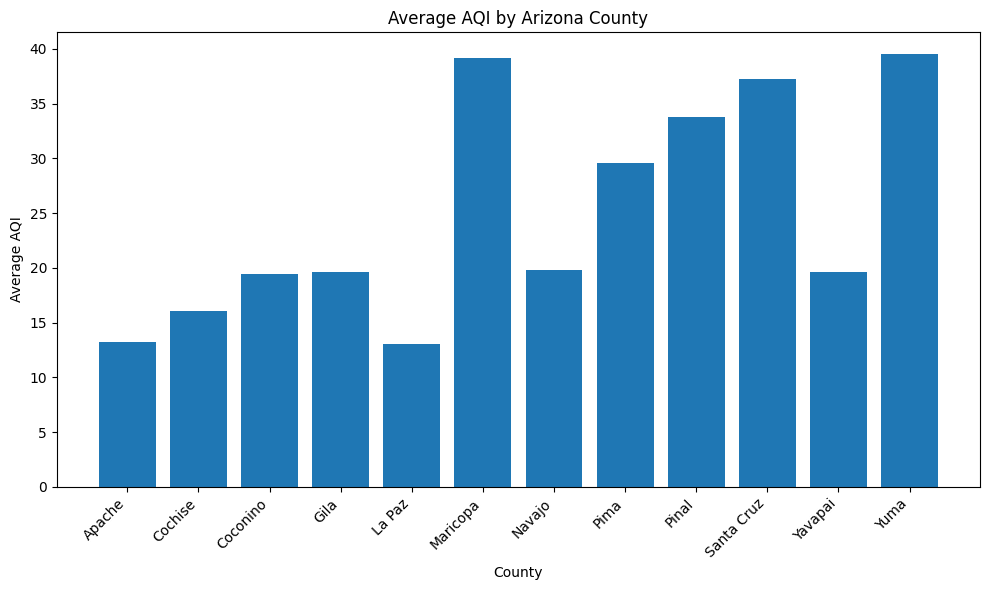

In [51]:
#Plot 1: Average AQI by County
plt.figure(figsize=(10,6))
plt.bar(joined_df["county_name"], joined_df["avg_aqi"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("County")
plt.ylabel("Average AQI")
plt.title("Average AQI by Arizona County")
plt.tight_layout()
plt.show()

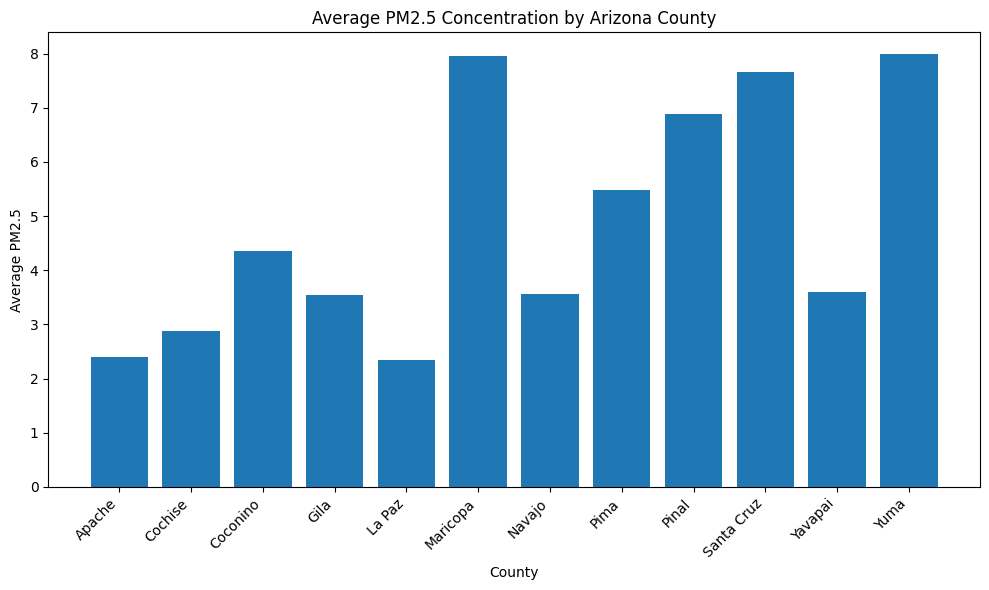

In [52]:
#Plot 2: PM2.5 by County
plt.figure(figsize=(10,6))
plt.bar(joined_df["county_name"], joined_df["avg_pm25"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("County")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 Concentration by Arizona County")
plt.tight_layout()

plt.show()

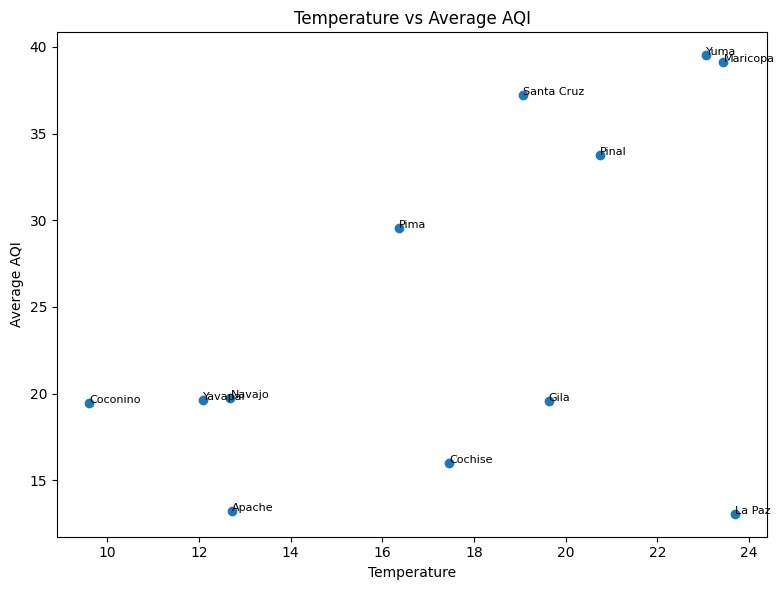

In [54]:
#Plot 3: Temperature vs AQI
plt.figure(figsize=(8,6))
plt.scatter(joined_df["temperature"], joined_df["avg_aqi"])

for i, row in joined_df.iterrows():
    plt.text(row["temperature"], row["avg_aqi"], row["county_name"], fontsize=8)

plt.xlabel("Temperature")
plt.ylabel("Average AQI")
plt.title("Temperature vs Average AQI")
plt.tight_layout()
plt.show()

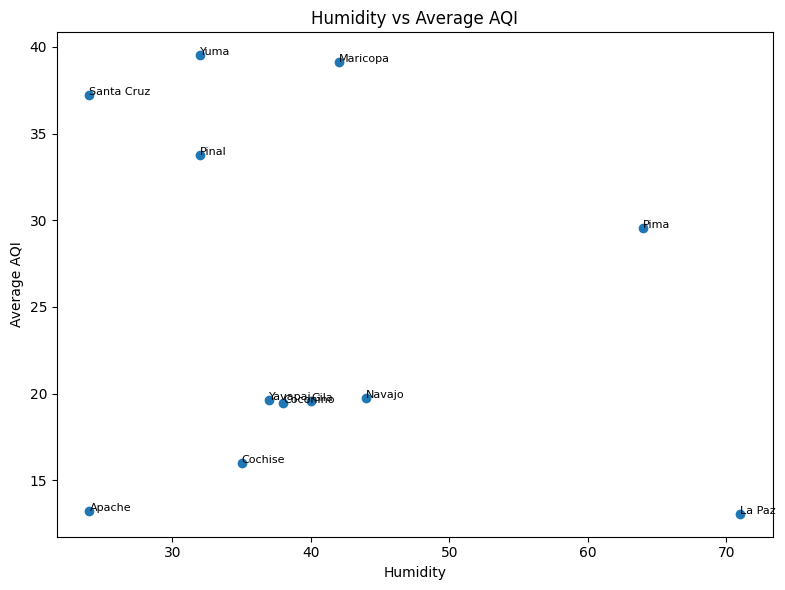

In [55]:
#Plot 4: Humidity vs AQI
plt.figure(figsize=(8,6))
plt.scatter(joined_df["humidity"], joined_df["avg_aqi"])

for i, row in joined_df.iterrows():
    plt.text(row["humidity"], row["avg_aqi"], row["county_name"], fontsize=8)

plt.xlabel("Humidity")
plt.ylabel("Average AQI")
plt.title("Humidity vs Average AQI")
plt.tight_layout()
plt.show()

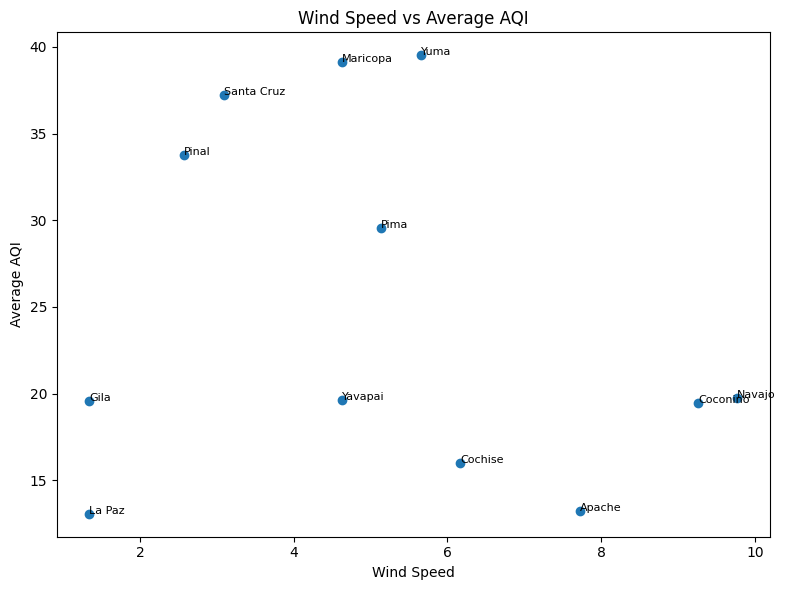

In [56]:
#Plot 5: Wind Speed vs AQI
plt.figure(figsize=(8,6))
plt.scatter(joined_df["wind_speed"], joined_df["avg_aqi"])

for i, row in joined_df.iterrows():
    plt.text(row["wind_speed"], row["avg_aqi"], row["county_name"], fontsize=8)

plt.xlabel("Wind Speed")
plt.ylabel("Average AQI")
plt.title("Wind Speed vs Average AQI")
plt.tight_layout()
plt.show()

### Visualization Summary

The plots show variation in AQI and PM2.5 levels across Arizona counties. The scatter plots compare air quality with temperature, humidity, and wind speed to explore possible relationships between weather conditions and pollution levels.

## Part 9: Final Findings and Conclusion

In this section, I summarize the key findings from the analysis of air quality and weather data across Arizona counties.

### Key Findings

1. **Variation in Air Quality Across Counties**
   - The analysis showed noticeable differences in average AQI levels across Arizona counties.
   - Some counties consistently exhibited higher pollution levels, indicating potential environmental or urban factors.

2. **Temperature and Air Quality Relationship**
   - There appears to be a mild relationship between temperature and AQI.
   - Warmer counties tend to show slightly higher AQI values, although the relationship is not strongly linear.

3. **Impact of Humidity**
   - Humidity showed some variation across counties but did not display a strong direct relationship with AQI.
   - This suggests that humidity alone may not be a major driver of pollution levels.

4. **Wind Speed and Pollution**
   - Counties with higher wind speeds generally showed lower AQI values.
   - This supports the idea that wind helps disperse pollutants, improving air quality.

5. **PM2.5 and AQI Consistency**
   - PM2.5 concentration closely aligns with AQI values, confirming that fine particulate matter is a key contributor to air pollution levels.

### Data Engineering Summary

This project successfully implemented a complete ETL pipeline:

- **Extract**:
  - Air quality data was collected from the EPA dataset.
  - Weather data was retrieved using the OpenWeather API.

- **Transform**:
  - The EPA dataset was cleaned and reduced to relevant columns.
  - Data was aggregated from site-level to county-level.
  - Weather data was mapped to counties using representative cities.
  - The datasets were merged into a unified analytical dataset.

- **Load**:
  - The processed data was loaded into a PostgreSQL database hosted on Aiven.
  - A normalized relational schema was created with separate tables for counties, weather, and air quality.

- **Querying and Analysis**:
  - SQL queries were used to explore relationships and answer key analytical questions.
  - Visualizations were created to identify trends and patterns.

### Challenges

- Matching counties with cities for weather data required manual mapping due to API limitations.
- Ensuring consistency between datasets required validation and debugging during merging.
- Managing multiple data sources (CSV and API) required careful structuring of the ETL pipeline.

### Conclusion

This project demonstrates how integrating multiple data sources can provide valuable insights into environmental patterns. By combining air quality and weather data, it was possible to explore how atmospheric conditions may influence pollution levels. The project highlights the importance of data cleaning, transformation, and structured storage in enabling meaningful analysis.

## Extra Credit: Streamlit App

In [1]:
!pip install streamlit

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

st.set_page_config(page_title="Arizona Air Quality Dashboard", layout="wide")

st.title("Arizona Air Quality and Weather Dashboard")
st.write("""
This Streamlit app displays the final results from my data engineering project.
It connects to the PostgreSQL database, loads the cleaned county-level air quality
and weather data, and provides interactive visualizations.
""")

# Database connection
DB_HOST = "HOST"
DB_NAME = "NAME"
DB_USER = "USER"
DB_PASSWORD = "PASSWORD"
DB_PORT = "PORT"


@st.cache_data
def load_data():
    conn = psycopg2.connect(
        host=DB_HOST,
        database=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        port=DB_PORT
    )

    query = """
    SELECT
        c.county_name,
        a.avg_aqi,
        a.avg_pm25,
        w.city,
        w.temperature,
        w.humidity,
        w.wind_speed
    FROM counties c
    JOIN air_quality a ON c.county_id = a.county_id
    JOIN weather w ON c.county_id = w.county_id;
    """

    df = pd.read_sql(query, conn)
    conn.close()
    return df

df = load_data()

st.subheader("Final Integrated Dataset")
st.dataframe(df)

st.subheader("Key Metrics")

col1, col2, col3 = st.columns(3)

col1.metric("Average AQI", round(df["avg_aqi"].mean(), 2))
col2.metric("Average PM2.5", round(df["avg_pm25"].mean(), 2))
col3.metric("Counties Analyzed", df["county_name"].nunique())

st.subheader("Filter by County")

selected_counties = st.multiselect(
    "Select counties to view",
    options=df["county_name"].unique(),
    default=df["county_name"].unique()
)

filtered_df = df[df["county_name"].isin(selected_counties)]

st.subheader("Average AQI by County")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(filtered_df["county_name"], filtered_df["avg_aqi"])
ax.set_xlabel("County")
ax.set_ylabel("Average AQI")
ax.set_title("Average AQI by County")
plt.xticks(rotation=45, ha="right")
st.pyplot(fig)

st.subheader("Temperature vs AQI")

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.scatter(filtered_df["temperature"], filtered_df["avg_aqi"])

for _, row in filtered_df.iterrows():
    ax2.text(row["temperature"], row["avg_aqi"], row["county_name"], fontsize=8)

ax2.set_xlabel("Temperature")
ax2.set_ylabel("Average AQI")
ax2.set_title("Temperature vs Average AQI")
st.pyplot(fig2)

st.subheader("Wind Speed vs AQI")

fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.scatter(filtered_df["wind_speed"], filtered_df["avg_aqi"])

for _, row in filtered_df.iterrows():
    ax3.text(row["wind_speed"], row["avg_aqi"], row["county_name"], fontsize=8)

ax3.set_xlabel("Wind Speed")
ax3.set_ylabel("Average AQI")
ax3.set_title("Wind Speed vs Average AQI")
st.pyplot(fig3)

st.subheader("Project Summary")

st.write("""
This dashboard shows how air quality varies across Arizona counties and how it relates
to weather conditions such as temperature, humidity, and wind speed. The data comes
from the EPA air quality dataset and the OpenWeather API, then was cleaned, transformed,
and loaded into PostgreSQL.
""")

Overwriting app.py


In [ ]:
# Ensuring pyngrok is installed
!pip install -q pyngrok

# Import ngrok
from pyngrok import ngrok

# Starting the Streamlit app
get_ipython().system_raw('python -m streamlit run app.py &')
ngrok.set_auth_token('NGRO_AUTH_TOKEN')

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://polish-overgrown-fling.ngrok-free.dev" -> "http://localhost:8501"
